# Korea Income & Welfare

## Academic Companion Notebook

This notebook is the academic-facing companion to the current portfolio version of the repository. It does not rerun the full modeling pipeline from raw data. Instead, it reads the validated outputs exported by [`scripts/income_welfare_analysis.py`](scripts/income_welfare_analysis.py) and organizes them into a more academic narrative.

### Abstract

The project studies how education relates to income in Korean welfare microdata. The current version combines descriptive analysis, formal distribution tests, predictive benchmarking, semilog OLS with robust inference, and quantile regression. The main analytical claim is that education has a clearly positive average income premium, but that premium is not uniform across the distribution.

### Core claim

Education is not just a predictive feature. It acts as a proxy for differentiated access to labor-market opportunities, and its payoff appears larger in better-paid parts of the income distribution.


In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display
import pandas as pd

BASE_DIR = Path.cwd()
required_paths = [
    BASE_DIR / 'outputs/tables/education_income_summary.csv',
    BASE_DIR / 'outputs/tables/statistical_tests.csv',
    BASE_DIR / 'outputs/tables/model_comparison.csv',
    BASE_DIR / 'outputs/tables/ml_cross_validation.csv',
    BASE_DIR / 'outputs/tables/econometric_ols_summary.csv',
    BASE_DIR / 'outputs/tables/econometric_diagnostics.csv',
    BASE_DIR / 'outputs/tables/econometric_vif.csv',
    BASE_DIR / 'outputs/tables/quantile_regression_summary.csv',
]
missing = [str(path.relative_to(BASE_DIR)) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing expected outputs: {missing}')
print('All required outputs are available.')


All required outputs are available.


In [2]:
education_summary = pd.read_csv(BASE_DIR / 'outputs/tables/education_income_summary.csv')
region_summary = pd.read_csv(BASE_DIR / 'outputs/tables/region_income_summary.csv')
year_summary = pd.read_csv(BASE_DIR / 'outputs/tables/year_income_summary.csv')
statistical_tests = pd.read_csv(BASE_DIR / 'outputs/tables/statistical_tests.csv')
model_comparison = pd.read_csv(BASE_DIR / 'outputs/tables/model_comparison.csv')
ml_cv = pd.read_csv(BASE_DIR / 'outputs/tables/ml_cross_validation.csv')
feature_importance = pd.read_csv(BASE_DIR / 'outputs/tables/feature_importance.csv')
ols_summary = pd.read_csv(BASE_DIR / 'outputs/tables/econometric_ols_summary.csv')
diagnostics = pd.read_csv(BASE_DIR / 'outputs/tables/econometric_diagnostics.csv')
vif = pd.read_csv(BASE_DIR / 'outputs/tables/econometric_vif.csv')
quantile_summary = pd.read_csv(BASE_DIR / 'outputs/tables/quantile_regression_summary.csv')

education_premium = float(ols_summary.loc[ols_summary['term'] == 'education_level', 'approx_pct_effect'].iloc[0])
best_holdout = model_comparison.iloc[0]
best_cv = ml_cv.iloc[0]

summary = pd.DataFrame([
    {'metric': 'Valid analysis sample', 'value': '89,935'},
    {'metric': 'Trimmed modeling sample', 'value': '86,313'},
    {'metric': 'Average education premium', 'value': f'{education_premium:.2f}%'},
    {'metric': 'Best holdout model', 'value': f"{best_holdout['model']} (R^2={best_holdout['r2']:.3f})"},
    {'metric': 'Best cross-validated model', 'value': f"{best_cv['model']} (R^2={best_cv['cv_r2_mean']:.3f})"},
])
summary


,metric,value
0,Valid analysis sample,"89,935"
1,Trimmed modeling sample,"86,313"
2,Average education premium,12.47%
3,Best holdout model,Tuned random forest (R^2=0.645)
4,Best cross-validated model,Tuned random forest (R^2=0.649)


## 1. Theoretical motivation

The original project framed education and income as a genuine social question rather than a generic prediction task. That is the right place to start. Education can be interpreted as a bundle of human capital, credentials, and access to labor-market opportunities. If the premium to education is both large and heterogeneous, then the project becomes analytically more interesting than a simple feature ranking.

This notebook therefore asks three linked questions:

1. Does education visibly separate income distributions in the raw data?
2. How much predictive power is added once demographic and household controls are included?
3. Does the premium to education remain constant across the income distribution?


In [3]:
display(Markdown('### Education, region, and time summaries'))
display(education_summary)
display(region_summary.head(7))
display(year_summary.tail(8))


### Education, region, and time summaries

,education_label,respondents,median_income_usd,average_income_usd
0,No formal education (age 7+),9320,770.000000,1004.272414
1,Elementary school,20395,1204.545455,1668.621629
2,Middle school,12019,1923.636364,2491.257809
3,High school,25935,3144.545455,3790.162580
4,College,5873,3939.090909,4480.059187
5,University degree,13897,4531.818182,5402.184273
6,Master's degree,2217,5593.636364,6219.523809
7,Doctorate,279,6639.090909,8246.679700


,region_label,respondents,median_income_usd,average_income_usd
0,Seoul,14052,2883.636364,3764.263980
1,Gyeonggi,18918,2799.090909,3620.354203
2,South Chungcheong,7599,2452.727273,3498.145974
3,South Gyeongsang,15756,2174.090909,3184.946093
4,Gangwon and North Chungcheong,6683,2094.545455,2878.333125
5,Jeolla and Jeju,15228,1783.181818,2705.034977
6,North Gyeongsang,11699,1722.727273,2609.522904


,year,respondents,median_income_usd,average_income_usd
6,2011,7321,2271.818182,3083.307509
7,2012,7132,2390.909091,3256.965176
8,2013,6899,2366.363636,3334.446580
9,2014,6786,2401.818182,3414.964889
10,2015,6621,2531.818182,3579.776441
11,2016,6501,2649.090909,3708.307799
12,2017,6413,2710.909091,3843.794912
13,2018,6288,2735.909091,3914.669746


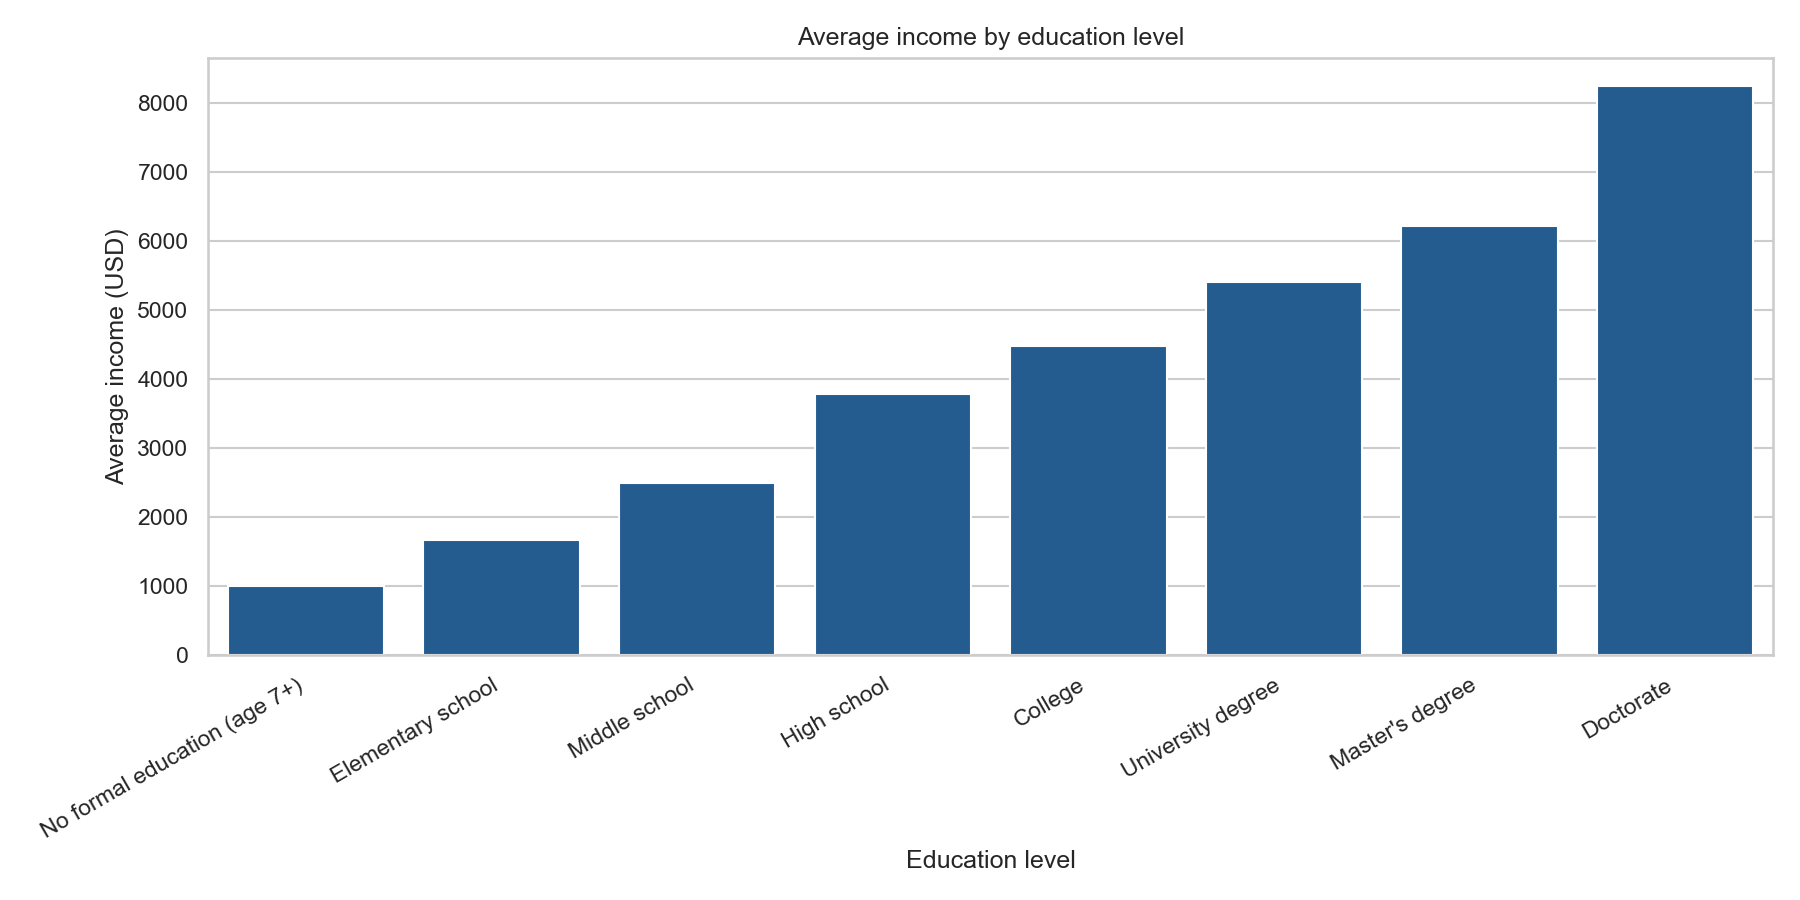

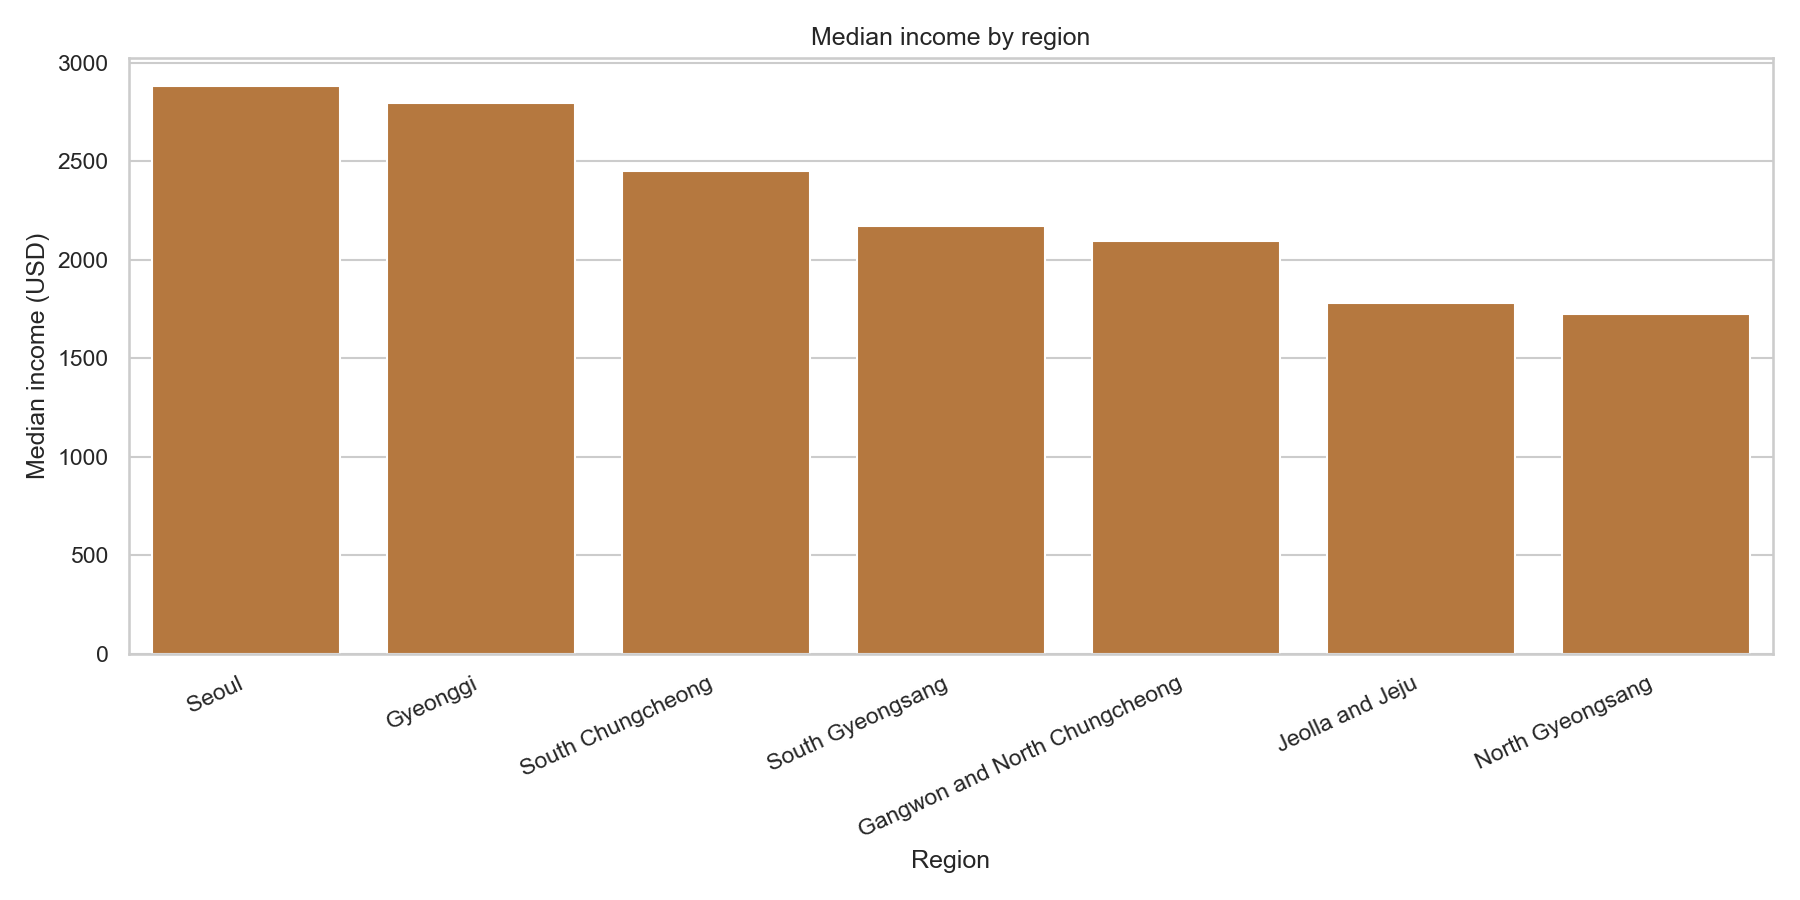

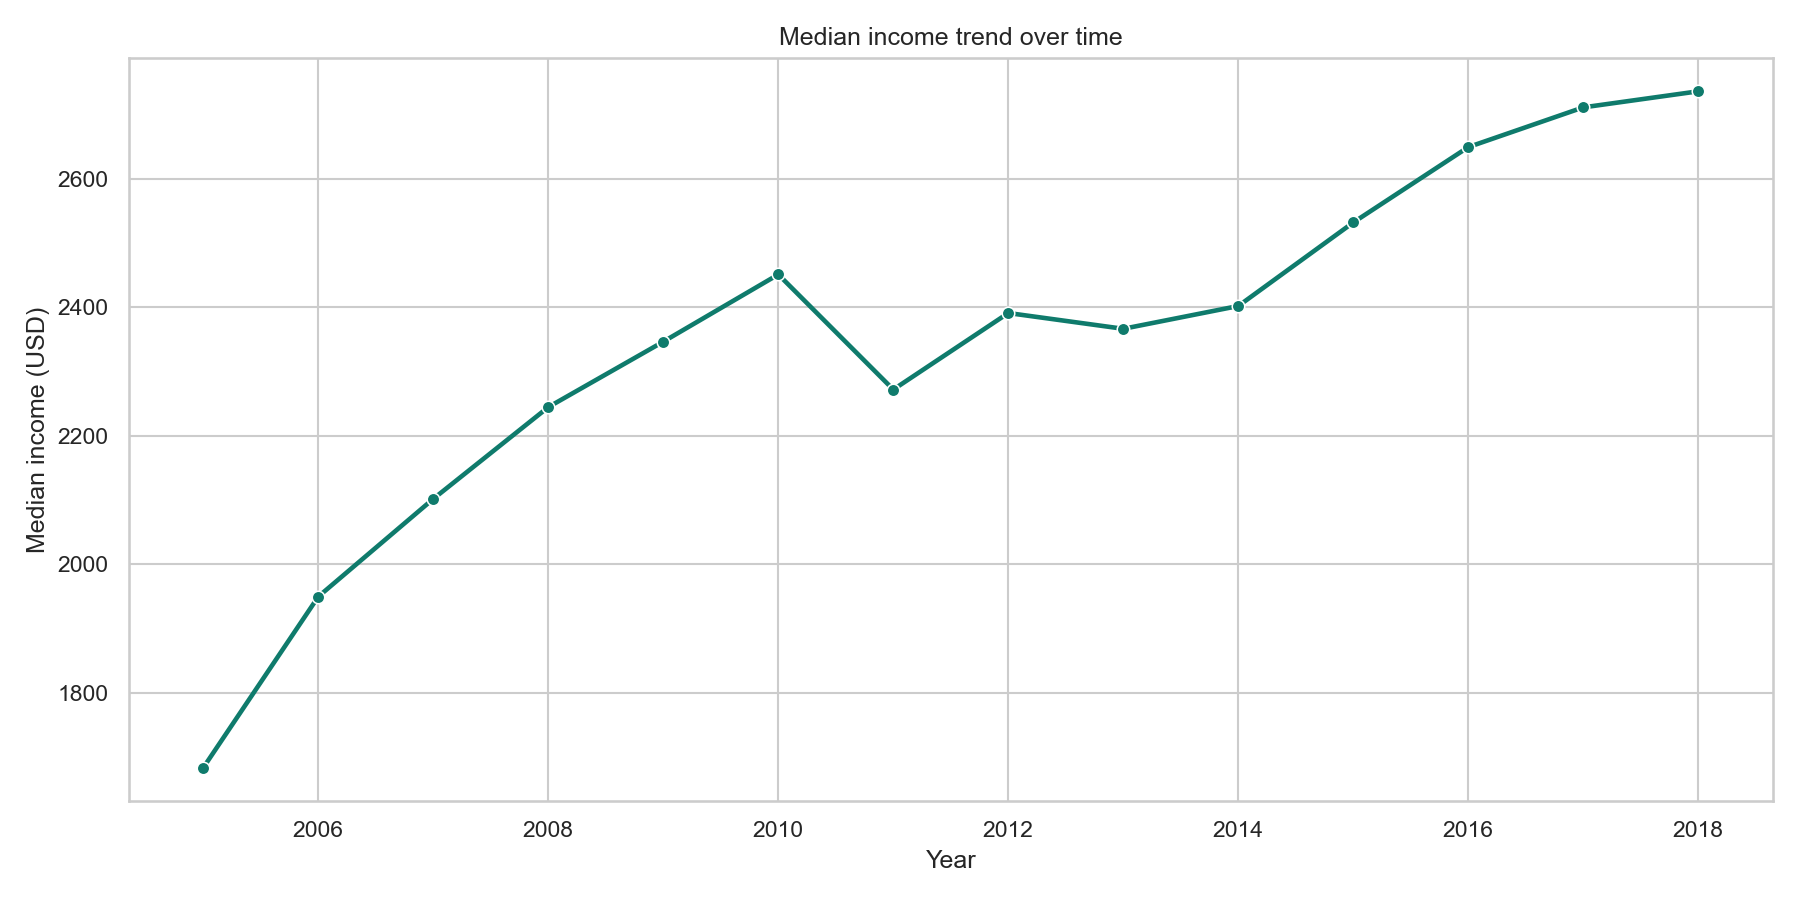

In [4]:
for figure_path in [
    BASE_DIR / 'outputs/figures/income_by_education.png',
    BASE_DIR / 'outputs/figures/median_income_by_region.png',
    BASE_DIR / 'outputs/figures/median_income_over_time.png',
]:
    display(Image(filename=str(figure_path), width=900))


## 2. Formal tests before modeling

The descriptive story is now backed by formal tests. This matters because it shows that the later models are motivated by strong empirical contrasts rather than only by intuition.

- Income distributions differ sharply across education levels.
- The rank correlation between education and income is strongly positive.
- Raw income distributions still differ by gender before conditioning on controls.


In [5]:
statistical_tests[['test_id', 'question', 'test', 'statistic', 'p_value', 'key_signal']]


,test_id,question,test,statistic,p_value,key_signal
0,K1,Do income distributions differ across educatio...,Kruskal-Wallis,3.393436e+04,0.0,Education groups show materially different inc...
1,K2,Is education monotonically associated with inc...,Spearman correlation,6.088177e-01,0.0,Higher education steps are strongly associated...
2,K3,Do men and women show different income distrib...,Mann-Whitney U,1.325071e+09,0.0,Raw income distributions still differ by gende...
3,K4,Does the trimmed modeling sample retain high e...,Sample check,2.094730e+03,NaN,The modeling sample keeps meaningful income di...


## 3. Predictive benchmarking

The predictive layer compares a simple education-only regression to richer multivariable and nonlinear models. This is important because it shows how much explanatory value comes from adding age, household structure, region, gender, religion, and time.

Two evaluation frames are reported:

- a holdout split,
- and five-fold cross-validation.

That makes the comparison more robust than a one-shot train/test result.


In [6]:
display(Markdown('### Holdout comparison'))
display(model_comparison)
display(Markdown('### Cross-validated comparison'))
display(ml_cv)
display(Markdown('### Top feature groups in the tuned random forest'))
display(feature_importance.head(10))


### Holdout comparison

,model,mae_usd,rmse_usd,r2
0,Tuned random forest,880.050114,1249.107373,0.645367
1,Gradient boosting,950.314893,1321.483372,0.603080
2,Elastic Net,1049.760912,1414.417418,0.545290
3,Multivariable linear regression,1049.827596,1414.492028,0.545242
4,Education-only linear regression,1345.399114,1762.556983,0.293901


### Cross-validated comparison

,model,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std
0,Tuned random forest,0.648669,0.003134,873.855601,2.266720,1241.558584,4.727394
1,Gradient boosting,0.599326,0.004341,952.618510,4.098399,1325.880258,7.487232
2,Multivariable linear regression,0.542070,0.003473,1050.655556,4.607919,1417.464887,6.632684
3,Elastic Net,0.542070,0.003439,1050.648361,4.577648,1417.465427,6.599929
4,Education-only linear regression,0.293862,0.005453,1342.825597,5.918949,1760.182884,8.673000


### Top feature groups in the tuned random forest

,feature_group,importance
0,family_member,0.478252
1,age,0.145617
2,education_level,0.143528
3,year,0.104161
4,region_label,0.056657
5,marriage_label,0.047958
6,religion_label,0.016085
7,gender_label,0.007740


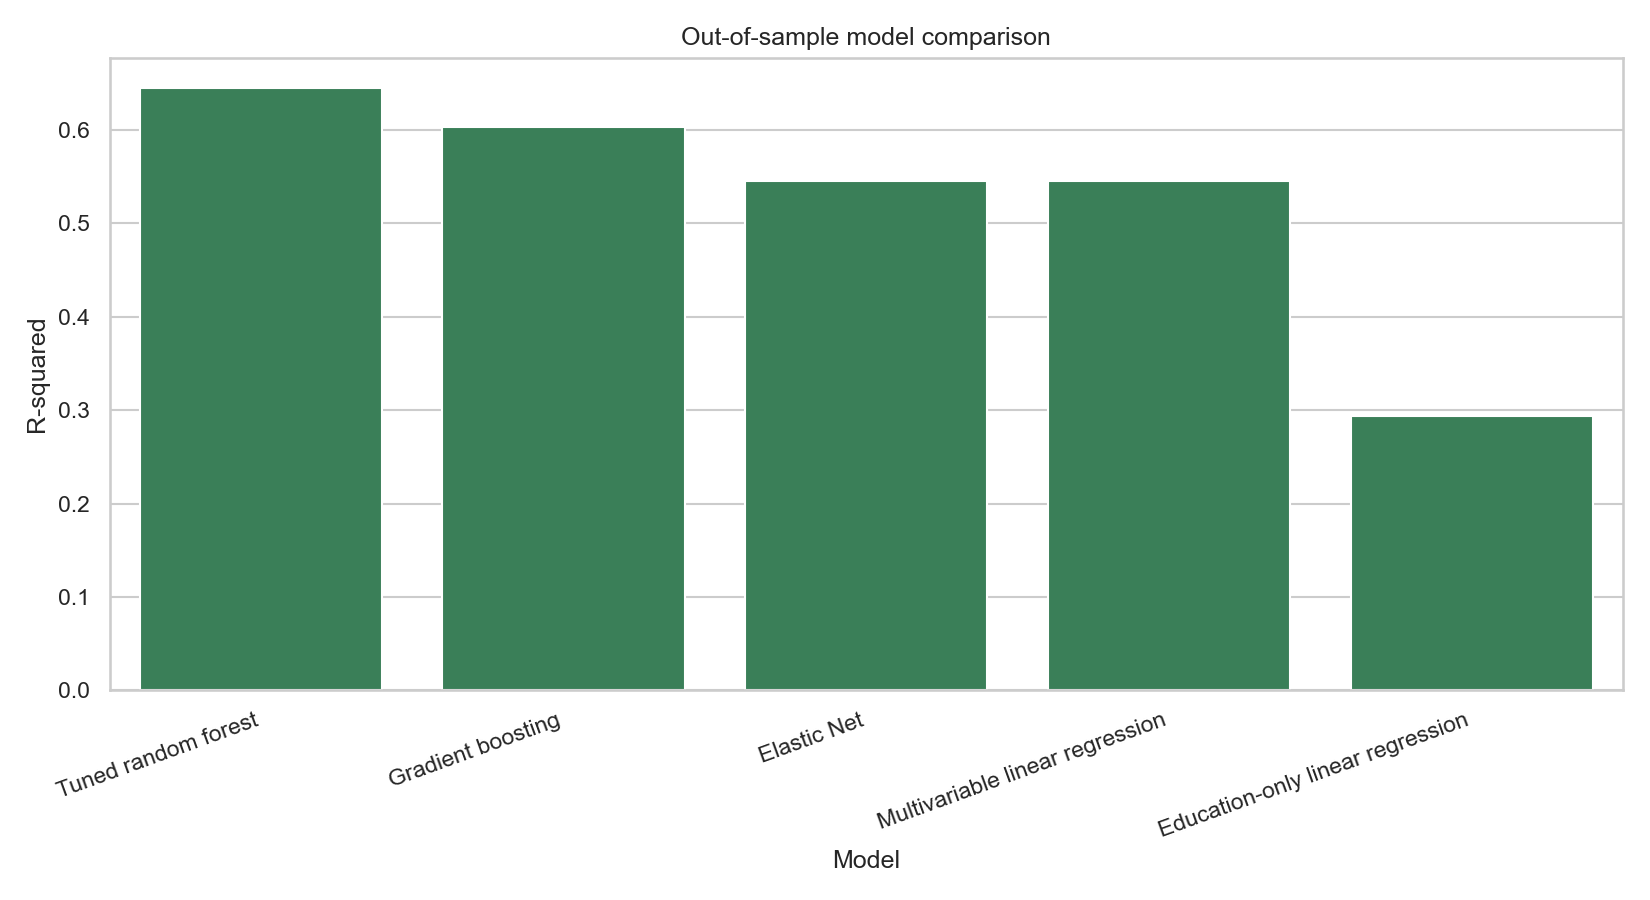

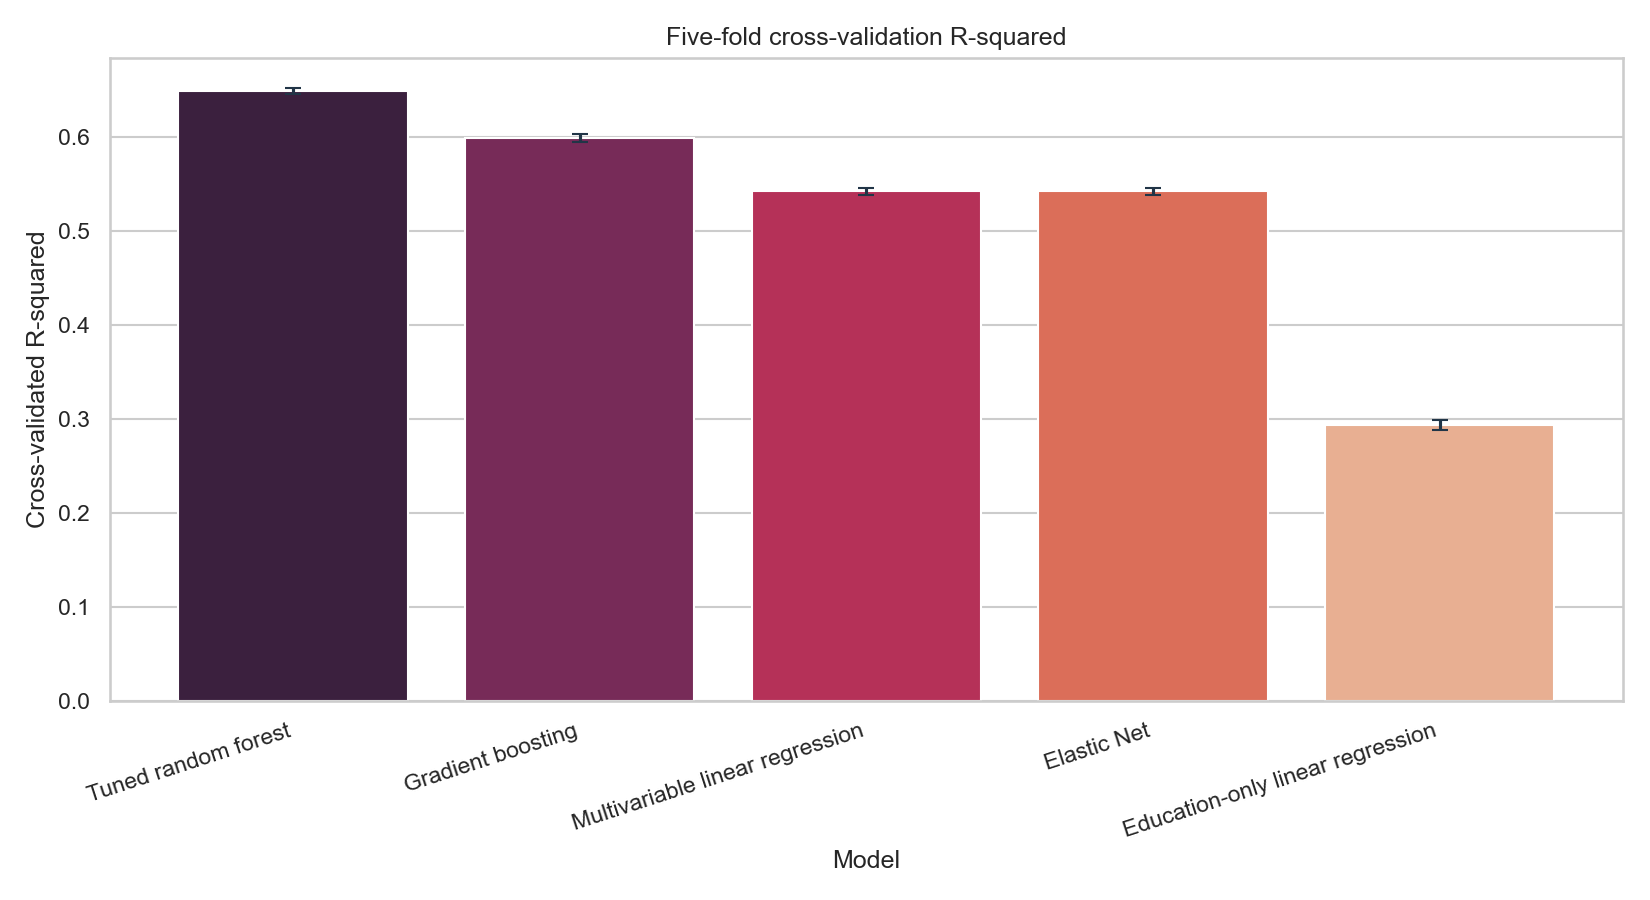

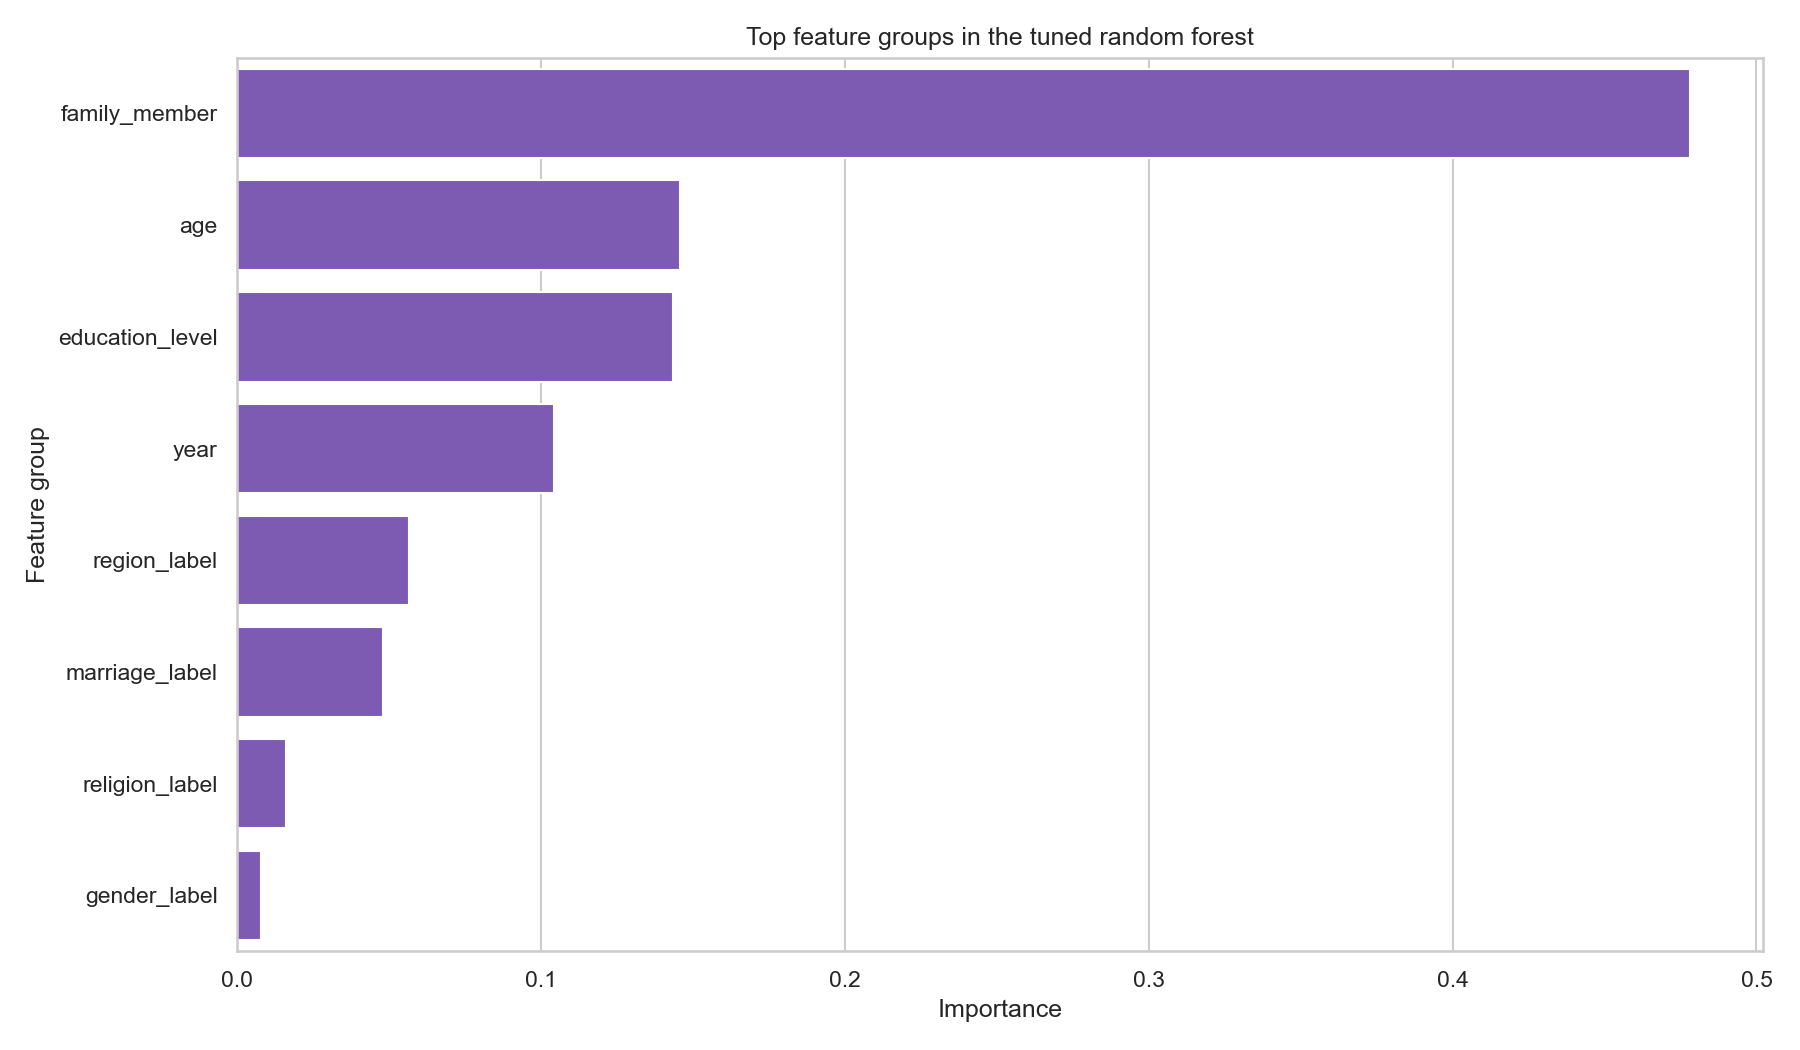

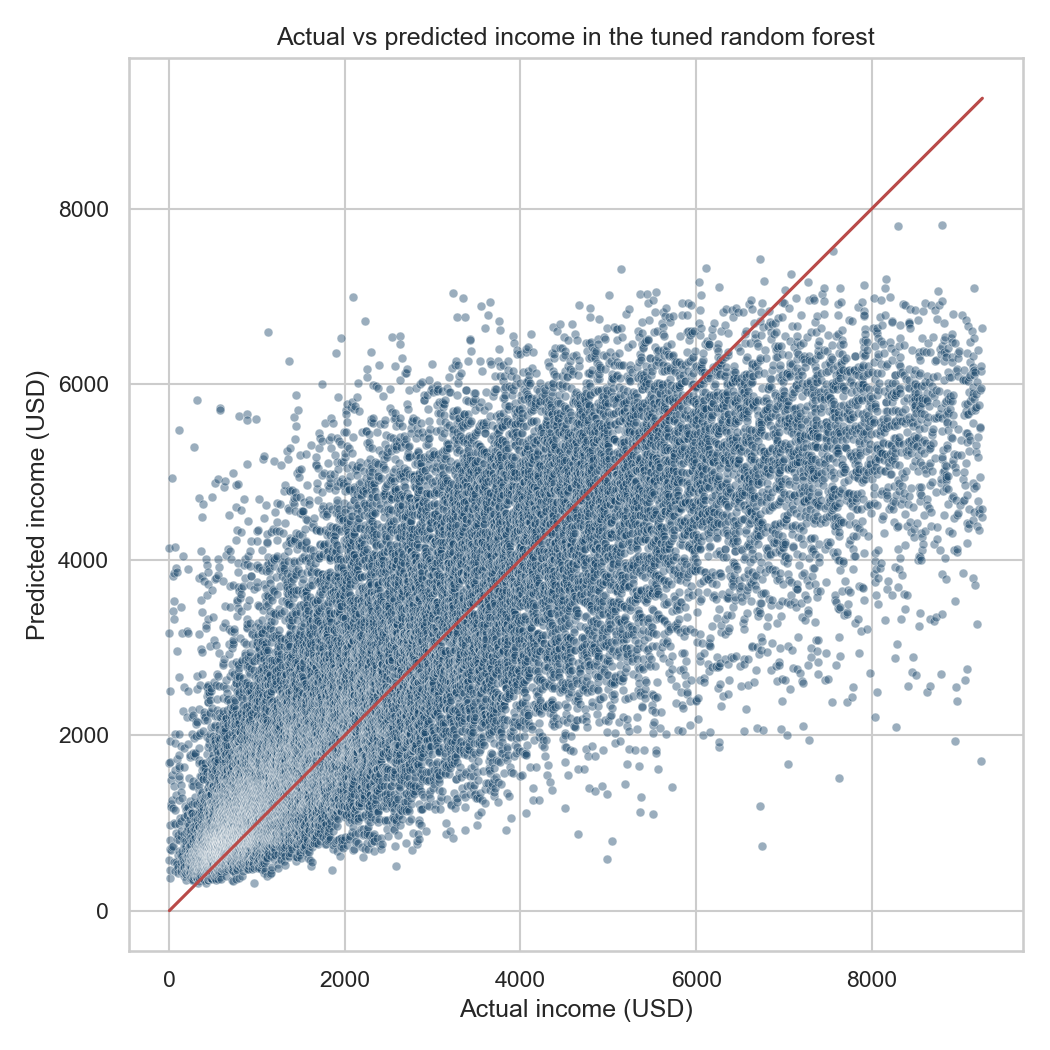

In [7]:
for figure_path in [
    BASE_DIR / 'outputs/figures/model_performance_r2.png',
    BASE_DIR / 'outputs/figures/ml_cross_validation_r2.png',
    BASE_DIR / 'outputs/figures/top_feature_importance.png',
    BASE_DIR / 'outputs/figures/actual_vs_predicted_income.png',
]:
    display(Image(filename=str(figure_path), width=900))


## 4. OLS interpretation and diagnostics

The semilog OLS model estimates the average premium to education while controlling for age, household size, region, gender, marital status, religion, and year. The age polynomial is centered before squaring, which materially improves the collinearity profile.

The diagnostics are part of the argument, not an appendix:

- heteroskedasticity is present, so robust inference is necessary;
- the RESET result indicates that the data retain meaningful nonlinear structure;
- VIF values stay in a manageable range once age is centered.


In [8]:
display(Markdown('### OLS coefficient summary'))
display(ols_summary)
display(Markdown('### OLS diagnostics'))
display(diagnostics)
display(Markdown('### Variance inflation factors'))
display(vif)


### OLS coefficient summary

,term,label,coefficient,std_error,p_value,ci_low,ci_high,approx_pct_effect
0,education_level,Education step premium,0.117503,0.001707,0.0,0.114157,0.120849,12.468488
1,age_centered,Age effect (centered),-0.014993,0.000198,0.0,-0.015381,-0.014605,-1.488140
2,I(age_centered ** 2),Age squared,-0.000377,0.000009,0.0,-0.000394,-0.000359,-0.037653
3,family_member,Household size effect,0.218222,0.002293,0.0,0.213728,0.222716,24.386326
4,year,Survey year trend,0.043681,0.000495,0.0,0.042711,0.044651,4.464873


### OLS diagnostics

,diagnostic,statistic,p_value,interpretation
0,Adjusted R-squared,0.600247,NaN,Share of log-income variation explained by the...
1,Breusch-Pagan LM,1010.158398,2.661680e-201,Tests whether residual variance changes system...
2,Breusch-Pagan F,51.093602,1.529520e-202,F-statistic version of the heteroskedasticity ...
3,RESET F,1514.599218,0.000000e+00,Signals whether additional nonlinear terms wou...
4,Jarque-Bera,221787.354228,0.000000e+00,Checks the normality of residuals in the semil...
5,Observations,86313.000000,NaN,Trimmed modeling sample used for the econometr...


### Variance inflation factors

,term,vif,interpretation
0,education_level,1.710352,Centered age terms keep multicollinearity at m...
1,age_centered,1.956206,Centered age terms keep multicollinearity at m...
2,age_centered_sq,1.178272,Centered age terms keep multicollinearity at m...
3,family_member,1.403965,Centered age terms keep multicollinearity at m...
4,year,1.031007,Centered age terms keep multicollinearity at m...


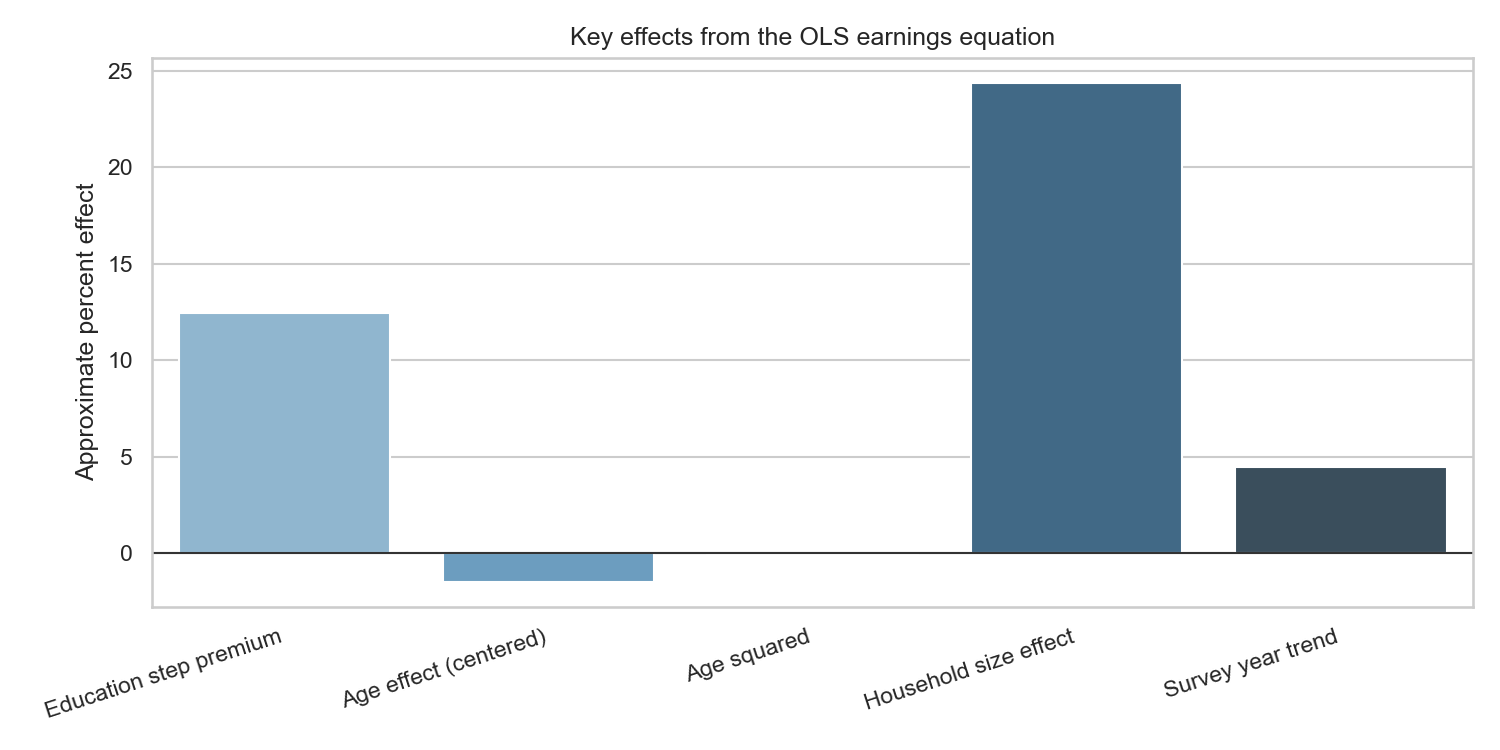

In [9]:
display(Image(filename=str(BASE_DIR / 'outputs/figures/ols_key_effects.png'), width=900))


## 5. Quantile regression and heterogeneous returns

The most substantive improvement in the project is the quantile-regression layer. Instead of assuming that education has a uniform average return everywhere in the distribution, the notebook estimates how the education coefficient changes across lower-income, median, and upper-income observations.

This is important because it turns the project from a generic supervised-learning case into a more economic question about differential rewards to schooling.


In [10]:
quantile_summary[['model', 'education_pct_premium', 'education_ci_low', 'education_ci_high', 'pseudo_r2']]


,model,education_pct_premium,education_ci_low,education_ci_high,pseudo_r2
0,Quantile regression (25th percentile),11.463226,0.104725,0.112324,0.418356
1,Quantile regression (50th percentile),13.840665,0.126227,0.133032,0.428280
2,Quantile regression (75th percentile),14.168495,0.128799,0.136211,0.385316


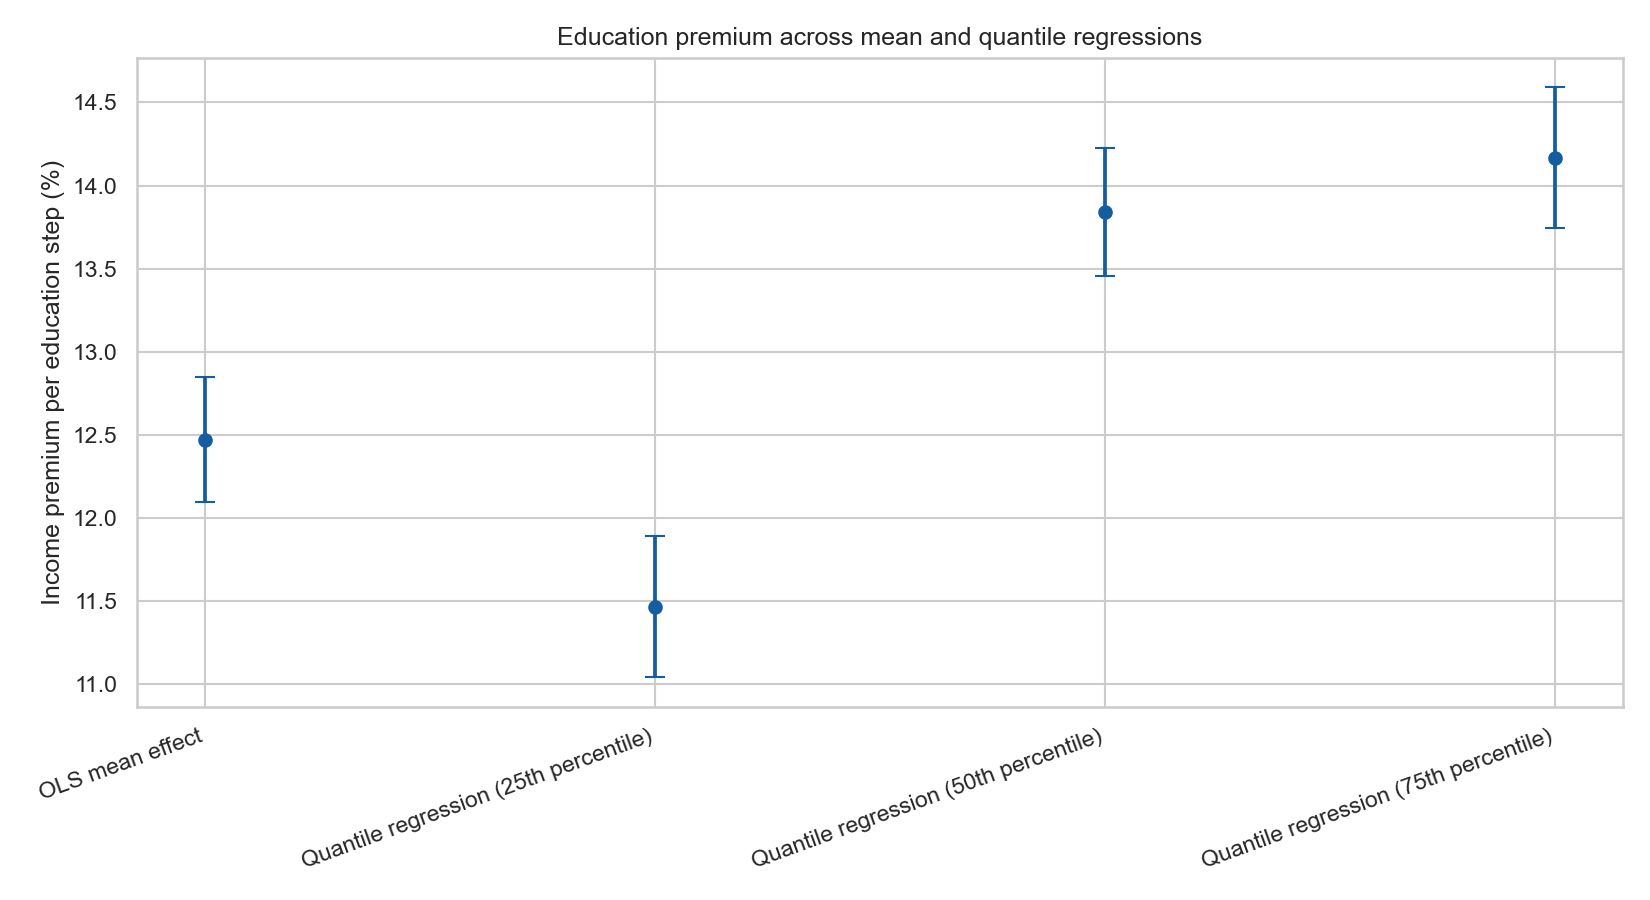

In [11]:
display(Image(filename=str(BASE_DIR / 'outputs/figures/education_premium_by_quantile.png'), width=900))


## 6. Conclusion

The project now supports a more interesting conclusion than the original notebook alone. Education has a strong positive average relationship with income, but the size of that premium rises across the income distribution. In parallel, the predictive benchmark shows that richer socioeconomic context materially improves accuracy beyond an education-only model.

Together, those results make the repository useful both as an ML case and as a more interpretable applied-economics case.
